# 01. Data preparation, EDA and feature engineering

## Цель

В этом ноутбуке формируется единый воспроизводимый набор данных для последующего обучения моделей предсказания цены автомобиля.

Последовательность работы:

1. Загружаем исходные train/test-данные и карточки автомобилей из `dataset_*`.
2. Собираем одну каноническую строку на каждый `car_id`.
3. Выполняем краткий EDA: проверяем размер данных, пропуски, распределение целевой переменной и потенциальную утечку.
4. Создаём числовые, возрастные и текстовые признаки из технических характеристик и названия автомобиля.
5. Сохраняем итоговые train/test-датасеты и схему признаков для `02_experiments_model_selection.ipynb` и `03_final_model_training.ipynb`.

> **Важно:** признак `Предложение` исключается из модельных признаков. Он почти повторяет цену в train, но в test преимущественно отсутствует, поэтому его использование является утечкой информации.


## 1. Импорты и пути проекта

Ниже определяются пути относительно корня проекта. Код не зависит от того, из какой папки Jupyter запускает notebook: корень находится автоматически по наличию папки `train_data`.


In [1]:
# ============================================================
# 1. PROJECT SETUP
# ============================================================

from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Ищем папку проекта независимо от текущей working directory.
current_path = Path.cwd().resolve()
possible_roots = [current_path, *current_path.parents]

PROJECT_ROOT = next(
    (
        path
        for path in possible_roots
        if (path / "train_data").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Не удалось определить корень проекта.\n"
        f"Текущая папка: {current_path}\n\n"
        "Ожидалась структура: shift_ml/train_data/"
    )

DATA_DIR = PROJECT_ROOT / "train_data"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

for directory in [PROCESSED_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
ID_COLUMN = "car_id"
TARGET_COLUMN = "Цена"
LEAKAGE_COLUMN = "Предложение"

pd.set_option("display.max_columns", 100)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", DATA_DIR)
print("Processed data directory:", PROCESSED_DIR)


Project root: C:\temp\shift_car_prices\shift_ml
Raw data directory: C:\temp\shift_car_prices\shift_ml\train_data
Processed data directory: C:\temp\shift_car_prices\shift_ml\data\processed


## 2. Загрузка исходных файлов и сборка canonical-таблиц

Целевая переменная хранится отдельно в `y_train_base.csv`, а исходные карточки автомобилей находятся в папках `dataset_*` и могут повторяться. Для train-объектов выбираем первое непустое значение каждого признака внутри одного `car_id`.

Предварительный аудит показал, что повторяющиеся карточки одного автомобиля не содержат конфликтующих непустых значений. Поэтому такая агрегация не теряет полезную информацию и приводит данные к одной строке на автомобиль.


In [2]:
# ============================================================
# 2. LOAD RAW DATA AND BUILD CANONICAL TABLES
# ============================================================


def read_dataset(path: Path) -> pd.DataFrame:
    """Читает один source-файл вне зависимости от формата."""
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".xlsx":
        return pd.read_excel(path)
    if suffix == ".json":
        try:
            return pd.read_json(path)
        except ValueError:
            return pd.read_json(path, lines=True)

    raise ValueError(f"Неподдерживаемый формат: {suffix}")


def dataset_number(path: Path) -> int:
    """Возвращает номер dataset_N для стабильной сортировки файлов."""
    return int(path.parent.name.split("_")[-1])


def first_non_null(series: pd.Series):
    """Берёт первое доступное значение внутри одного car_id."""
    values = series.dropna()
    return pd.NA if values.empty else values.iloc[0]


X_test_base = pd.read_csv(DATA_DIR / "X_test_base.csv")
y_train_base = pd.read_csv(DATA_DIR / "y_train_base.csv")

X_test_base[ID_COLUMN] = X_test_base[ID_COLUMN].astype("string").str.strip()
y_train_base[ID_COLUMN] = y_train_base[ID_COLUMN].astype("string").str.strip()

source_files = sorted(
    DATA_DIR.glob("dataset_*/data.*"),
    key=dataset_number,
)

if not source_files:
    raise FileNotFoundError(
        "Не найдены файлы dataset_*/data.* в train_data."
    )

source_parts = []
source_audit_rows = []

for path in source_files:
    source = read_dataset(path).copy()

    if ID_COLUMN not in source.columns:
        raise KeyError(f"В {path} отсутствует {ID_COLUMN}.")

    source[ID_COLUMN] = source[ID_COLUMN].astype("string").str.strip()
    source_parts.append(source)

    source_audit_rows.append(
        {
            "dataset": path.parent.name,
            "file": path.name,
            "rows": len(source),
            "unique_car_id": source[ID_COLUMN].nunique(),
            "duplicate_rows": int(source.duplicated().sum()),
        }
    )

train_source_raw = pd.concat(source_parts, ignore_index=True)
source_audit = pd.DataFrame(source_audit_rows)

# Все feature-колонки должны совпадать со структурой test.
base_feature_columns = [
    column
    for column in X_test_base.columns
    if column != ID_COLUMN
]

missing_source_columns = [
    column
    for column in base_feature_columns
    if column not in train_source_raw.columns
]

if missing_source_columns:
    raise KeyError(
        "В source-данных отсутствуют колонки: "
        f"{missing_source_columns}"
    )

# Одна каноническая строка на автомобиль.
X_train_canonical = (
    train_source_raw
    .groupby(ID_COLUMN, as_index=False)[base_feature_columns]
    .agg(first_non_null)
)

train_canonical = X_train_canonical.merge(
    y_train_base,
    on=ID_COLUMN,
    how="inner",
    validate="one_to_one",
)

X_test_canonical = X_test_base.copy()

# Проверки корректности сборки.
assert len(train_canonical) == len(y_train_base)
assert train_canonical[ID_COLUMN].nunique() == len(train_canonical)
assert X_test_canonical[ID_COLUMN].nunique() == len(X_test_canonical)
assert list(X_train_canonical.columns) == list(X_test_canonical.columns)
assert train_canonical[TARGET_COLUMN].notna().all()

print("Source rows:", len(train_source_raw))
print("Canonical train shape:", train_canonical.shape)
print("Canonical test shape:", X_test_canonical.shape)

print("\nSource audit:")
display(source_audit.head())

print("\nCanonical train sample:")
display(train_canonical.head(3))


Source rows: 49679
Canonical train shape: (8340, 23)
Canonical test shape: (8341, 22)

Source audit:


,dataset,file,rows,unique_car_id,duplicate_rows
0,dataset_1,data.csv,174,174,0
1,dataset_2,data.csv,1026,174,399
2,dataset_3,data.xlsx,1056,174,392
3,dataset_4,data.parquet,1076,174,411
4,dataset_5,data.parquet,993,174,383



Canonical train sample:


,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,Топливо,Расход,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев,Предложение,Цена
0,000b82cb-adcd-4e61-9b0a-8ef6f0d122a3,SUBARU,2018.0,WRX,SEDAN,2018 SUBARU WRX STI SPEC R (AWD),USED,Manual,"4 cyl, 2.5 L",AWD,PREMIUM,11.2 L / 100 km,29030,White / -,"SEAFORD, VIC",4 cyl,SEDAN,4 Doors,5 Seats,7.0,2.0,59265.0,61950
1,000f5560-2482-4127-8a77-2f34d0174741,SSANGYONG,2023.0,REXTON,HUNTER VALLEY MOTOR GROUP,2023 SSANGYONG REXTON ELX (AWD),NEW,Automatic,"4 cyl, 2.2 L",AWD,DIESEL,8.7 L / 100 km,7,White / -,"RUTHERFORD, NSW",4 cyl,SUV,4 Doors,7 Seats,4.0,2.0,40391.0,48990
2,0011dbaa-8c63-4055-8e08-c2ddd5b4c053,NISSAN,2011.0,X-TRAIL,SUV,2011 NISSAN X-TRAIL ST (4X4),USED,Manual,"4 cyl, 2.5 L",4WD,UNLEADED,9.1 L / 100 km,248318,Grey / -,"FYSHWICK, ACT",4 cyl,SUV,4 Doors,5 Seats,9.0,2.0,7512.0,8549


## 3. Краткий EDA

На этом этапе проверяем свойства данных, которые важны для моделирования:

- размер train/test и пропуски;
- распределение целевой переменной `Цена`;
- потенциальную утечку в `Предложение`;
- сопоставимость train и test по пропускам.

Подробное расследование всех промежуточных источников в финальный notebook не включается: важен воспроизводимый путь от raw-данных к итоговому набору признаков.


=== DATASET SHAPES ===


,dataset,rows,columns,unique_car_id
0,train,8340,23,8340
1,test,8341,22,8341


=== TARGET SUMMARY ===


,metric,value
0,Количество объектов,8.340000e+03
1,Пропусков,0.000000e+00
2,Минимум,9.000000e+02
3,Медиана,2.962000e+04
4,Среднее,3.712697e+04
5,95-й процентиль,8.688800e+04
6,Максимум,1.500000e+06


=== TOP MISSING FEATURES ===


,train_missing_pct,test_missing_pct,abs_difference_pct
Количество кресел,9.76,10.48,0.72
Двери,9.20,9.83,0.63
Локация,2.55,2.83,0.28
Тип кузова,1.59,1.75,0.16
Тип машины,0.16,0.16,0.00
car_id,0.00,0.00,0.00
Полное название,0.00,0.00,0.00
Модель,0.00,0.00,0.00
Год выпуска,0.00,0.00,0.00
Бренд,0.00,0.00,0.00


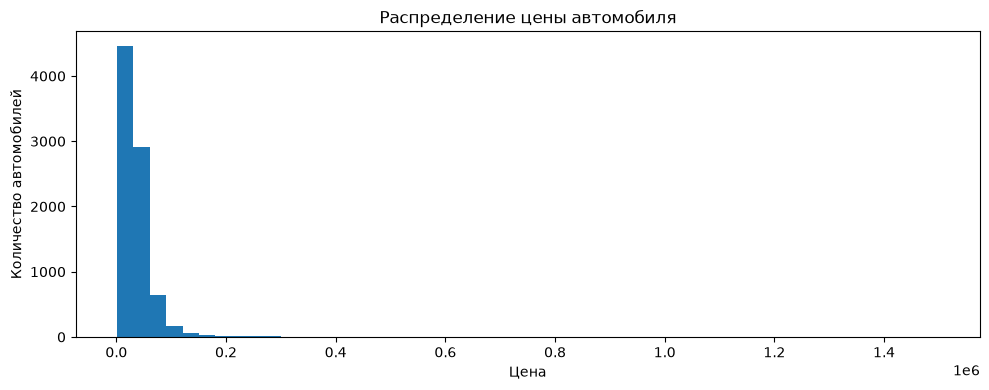

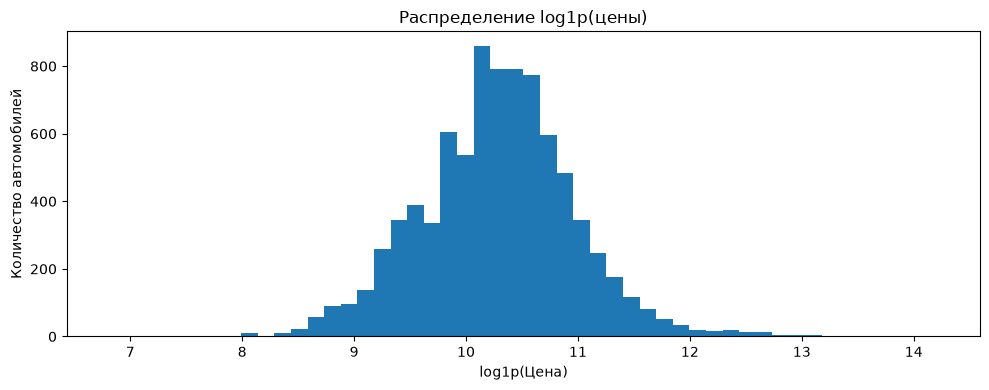

In [3]:
# ============================================================
# 3. BASIC EDA
# ============================================================

y = train_canonical[TARGET_COLUMN].copy()

shape_report = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train_canonical), len(X_test_canonical)],
        "columns": [train_canonical.shape[1], X_test_canonical.shape[1]],
        "unique_car_id": [
            train_canonical[ID_COLUMN].nunique(),
            X_test_canonical[ID_COLUMN].nunique(),
        ],
    }
)

missingness_report = pd.DataFrame(
    {
        "train_missing_pct": (
            X_train_canonical.isna().mean() * 100
        ),
        "test_missing_pct": (
            X_test_canonical.isna().mean() * 100
        ),
    }
)
missingness_report["abs_difference_pct"] = (
    missingness_report["train_missing_pct"]
    - missingness_report["test_missing_pct"]
).abs()
missingness_report = missingness_report.sort_values(
    "train_missing_pct",
    ascending=False,
)

target_report = pd.DataFrame(
    {
        "metric": [
            "Количество объектов",
            "Пропусков",
            "Минимум",
            "Медиана",
            "Среднее",
            "95-й процентиль",
            "Максимум",
        ],
        "value": [
            len(y),
            int(y.isna().sum()),
            y.min(),
            y.median(),
            y.mean(),
            y.quantile(0.95),
            y.max(),
        ],
    }
)

print("=== DATASET SHAPES ===")
display(shape_report)

print("=== TARGET SUMMARY ===")
display(target_report)

print("=== TOP MISSING FEATURES ===")
display(missingness_report.head(12).round(2))

plt.figure(figsize=(10, 4))
plt.hist(y, bins=50)
plt.title("Распределение цены автомобиля")
plt.xlabel("Цена")
plt.ylabel("Количество автомобилей")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(np.log1p(y), bins=50)
plt.title("Распределение log1p(цены)")
plt.xlabel("log1p(Цена)")
plt.ylabel("Количество автомобилей")
plt.tight_layout()
plt.show()


### Проверка потенциальной утечки `Предложение`

В train этот столбец похож на цену объявления и почти напрямую связан с целевой переменной. При этом в test он во многих строках отсутствует. Поэтому даже если значение даёт сильную корреляцию на train, включать его в модель нельзя: это информация, недоступная в финальном предсказании.


In [4]:
# ============================================================
# 4. LEAKAGE AUDIT
# ============================================================

offer_numeric = pd.to_numeric(
    train_canonical[LEAKAGE_COLUMN],
    errors="coerce",
)

offer_mask = offer_numeric.notna() & y.notna()

offer_mape = np.nan

if offer_mask.any():
    offer_mape = (
        np.abs(
            y.loc[offer_mask].to_numpy()
            - offer_numeric.loc[offer_mask].to_numpy()
        )
        / y.loc[offer_mask].to_numpy()
    ).mean() * 100

offer_audit = pd.DataFrame(
    {
        "metric": [
            "Непустых значений в train, %",
            "Непустых значений в test, %",
            "Корреляция Предложение и Цена",
            "MAPE Предложение как прямого прогноза",
        ],
        "value": [
            round(offer_numeric.notna().mean() * 100, 2),
            round(
                pd.to_numeric(
                    X_test_canonical[LEAKAGE_COLUMN],
                    errors="coerce",
                ).notna().mean() * 100,
                2,
            ),
            round(offer_numeric.loc[offer_mask].corr(y.loc[offer_mask]), 6),
            round(offer_mape, 6),
        ],
    }
)

display(offer_audit)

print(
    "Вывод: Предложение исключается из итоговых признаков "
    "как потенциальная утечка."
)


,metric,value
0,"Непустых значений в train, %",100.000000
1,"Непустых значений в test, %",0.000000
2,Корреляция Предложение и Цена,0.993841
3,MAPE Предложение как прямого прогноза,8.311785


Вывод: Предложение исключается из итоговых признаков как потенциальная утечка.


## 4. Feature engineering

Создаём признаки в трёх группах:

1. **Технические числовые признаки**: пробег, расход, объём двигателя, цилиндры, двери, места и штат.
2. **Признаки эксплуатации**: возраст автомобиля, логарифм пробега и пробег на год эксплуатации.
3. **Признаки из названия**: нормализованное название, префиксы, элементы комплектации, мощность и флаги версий (`AMG`, `RS`, `TDI`, `QUATTRO` и другие).

Исходные строковые колонки `Пробег`, `Расход`, `Количество цилиндров`, `Двери` и `Количество кресел` исключаются из итоговой модели после извлечения чисел. Полное название и цвет также не подаются в CatBoost напрямую: вместо них используются более устойчивые производные признаки.


In [5]:
# ============================================================
# 5. FEATURE ENGINEERING FUNCTIONS
# ============================================================

MISSING_TOKENS = {
    "",
    "-",
    "null",
    "none",
    "nan",
    "n/a",
    "na",
}


def normalize_text_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Приводит текстовые обозначения пропусков к pd.NA."""
    result = df.copy()

    for column in result.columns:
        if column == ID_COLUMN:
            continue

        if (
            pd.api.types.is_object_dtype(result[column])
            or pd.api.types.is_string_dtype(result[column])
        ):
            cleaned = result[column].astype("string").str.strip()
            result[column] = cleaned.mask(
                cleaned.str.lower().isin(MISSING_TOKENS),
                pd.NA,
            )

    return result


def add_parsed_features(df: pd.DataFrame) -> pd.DataFrame:
    """Извлекает числа из технических строк, сохраняя исходные поля."""
    result = df.copy()

    result["Пробег_число"] = pd.to_numeric(
        result["Пробег"],
        errors="coerce",
    )

    result["Расход_л_на_100км"] = pd.to_numeric(
        result["Расход"]
        .astype("string")
        .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
        errors="coerce",
    )

    engine = result["Двигатель"].astype("string")

    result["Двигатель_цилиндры"] = pd.to_numeric(
        engine.str.extract(r"(\d+)\s*cyl", expand=False),
        errors="coerce",
    )

    result["Двигатель_объём_л"] = pd.to_numeric(
        engine.str.extract(r"(\d+(?:\.\d+)?)\s*L\b", expand=False),
        errors="coerce",
    )

    result["Двери_число"] = pd.to_numeric(
        result["Двери"]
        .astype("string")
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )

    result["Кресла_число"] = pd.to_numeric(
        result["Количество кресел"]
        .astype("string")
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )

    result["Штат"] = (
        result["Локация"]
        .astype("string")
        .str.extract(r",\s*([A-Z]{2,3})$", expand=False)
    )

    return result


def add_age_mileage_features(df: pd.DataFrame) -> pd.DataFrame:
    """Создаёт признаки возраста и интенсивности эксплуатации."""
    result = df.copy()

    result["Возраст_авто"] = np.maximum(
        2026 - pd.to_numeric(result["Год выпуска"], errors="coerce"),
        0,
    )

    result["Лог_пробег"] = np.log1p(result["Пробег_число"])

    result["Пробег_на_год"] = (
        result["Пробег_число"]
        / np.maximum(result["Возраст_авто"], 1)
    )

    result["Лог_пробег_на_год"] = np.log1p(
        result["Пробег_на_год"]
    )

    return result


def _normalise_title(series: pd.Series) -> pd.Series:
    """Нормализует регистр, пробелы и пунктуацию названия."""
    return (
        series.astype("string")
        .fillna("")
        .str.upper()
        .str.replace(r"[^A-Z0-9.]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def _first_tokens(series: pd.Series, n_tokens: int) -> pd.Series:
    """Возвращает первые n токенов текстовой строки."""
    return series.str.split().str[:n_tokens].str.join(" ")


def _extract_trim_tail(
    title: str,
    brand: str,
    model: str,
) -> str:
    """Удаляет год, марку и модель, оставляя хвост комплектации."""
    value = "" if pd.isna(title) else str(title).upper()
    value = re.sub(r"^\s*\d{4}\s+", "", value)

    for token in [brand, model]:
        if pd.notna(token) and str(token).strip():
            pattern = re.escape(str(token).upper().strip())
            value = re.sub(pattern, " ", value, count=1)

    value = re.sub(r"[^A-Z0-9.]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


def add_title_hierarchy_features(df: pd.DataFrame) -> pd.DataFrame:
    """Извлекает признаки поколения, комплектации и специальных версий."""
    result = df.copy()

    title = _normalise_title(result["Полное название"])
    title_without_year = title.str.replace(
        r"^\d{4}\s+",
        "",
        regex=True,
    )

    result["Название_без_года"] = title_without_year
    result["Название_нормализованное_без_года"] = title_without_year
    result["Название_префикс_2"] = _first_tokens(title_without_year, 2)
    result["Название_префикс_3"] = _first_tokens(title_without_year, 3)
    result["Название_префикс_4"] = _first_tokens(title_without_year, 4)
    result["Название_число_слов"] = title_without_year.str.split().str.len()

    result["Название_мощность_kw"] = pd.to_numeric(
        title_without_year.str.extract(
            r"\b(\d{2,3})\s*KW\b",
            expand=False,
        ),
        errors="coerce",
    )

    result["Название_есть_мощность_kw"] = (
        result["Название_мощность_kw"].notna().astype(int)
    )

    result["Название_моторный_маркер"] = title_without_year.str.extract(
        r"\b(TDI|TSI|TFSI|CDI|MHEV|PHEV|HYBRID|V[0-9]|[0-9]{2,3}KW)\b",
        expand=False,
    )

    title_tail = pd.Series(
        [
            _extract_trim_tail(title_value, brand, model)
            for title_value, brand, model in zip(
                result["Полное название"],
                result["Бренд"],
                result["Модель"],
            )
        ],
        index=result.index,
        dtype="string",
    )

    result["Название_комплектация_1"] = _first_tokens(title_tail, 1)
    result["Название_комплектация_2"] = _first_tokens(title_tail, 2)
    result["Название_комплектация_3"] = _first_tokens(title_tail, 3)
    result["Название_первые_2"] = _first_tokens(title_without_year, 2)
    result["Название_первые_3"] = _first_tokens(title_without_year, 3)
    result["Название_число_токенов"] = title_tail.str.split().str.len()

    title_flag_patterns = {
        "4X4": r"\b4X4\b|\b4WD\b",
        "AWD": r"\bAWD\b",
        "TURBO": r"\bTURBO\b",
        "SPORT": r"\bSPORT\b",
        "HYBRID": r"\bHYBRID\b|\bMHEV\b|\bPHEV\b",
        "GT": r"\bGT\b",
        "LUXURY": r"\bLUXURY\b",
        "DIESEL": r"\bDIESEL\b",
        "AMG": r"\bAMG\b",
        "M_SPORT": r"\bM SPORT\b|\bMSPORT\b",
        "RS": r"\bRS\b",
        "S_LINE": r"\bS LINE\b|\bSLINE\b",
        "GTI": r"\bGTI\b",
        "HSE": r"\bHSE\b",
        "SR5": r"\bSR5\b",
        "GXL": r"\bGXL\b",
        "LIMITED": r"\bLIMITED\b",
        "PREMIUM": r"\bPREMIUM\b",
        "COMFORTLINE": r"\bCOMFORTLINE\b",
        "ASCENT": r"\bASCENT\b",
        "ACTIVE": r"\bACTIVE\b",
        "ELITE": r"\bELITE\b",
        "TDI": r"\bTDI\b",
        "TSI": r"\bTSI\b",
        "TFSI": r"\bTFSI\b",
        "CDI": r"\bCDI\b",
        "V6": r"\bV6\b",
        "V8": r"\bV8\b",
        "QUATTRO": r"\bQUATTRO\b",
        "XDRIVE": r"\bXDRIVE\b",
        "4MATIC": r"\b4MATIC\b",
        "ALLGRIP": r"\bALLGRIP\b",
        "ALLTRACK": r"\bALLTRACK\b",
        "EQUIPPED": r"\bEQUIPPED\b",
    }

    for flag_name, pattern in title_flag_patterns.items():
        result[f"Название_флаг_{flag_name}"] = (
            title_without_year.str.contains(
                pattern,
                regex=True,
                na=False,
            ).astype(int)
        )

    return result


def build_v8_feature_table(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Строит полный набор детерминированных признаков для V8-пайплайна."""
    result = normalize_text_missing_values(raw_df)
    result = add_parsed_features(result)
    result = add_age_mileage_features(result)
    result = add_title_hierarchy_features(result)
    return result


### Формирование итогового V8 feature set

Перед обучением исключаем технический идентификатор, целевую переменную, потенциальную утечку и исходные дублирующие строковые поля. Категориальные признаки приводятся к строке и получают единый маркер пропуска `__MISSING__`, чтобы train и test имели одинаковую схему для CatBoost и линейных моделей.


In [6]:
# ============================================================
# 6. BUILD FINAL V8 FEATURES
# ============================================================

train_features_all = build_v8_feature_table(
    train_canonical.drop(columns=[TARGET_COLUMN])
)
test_features_all = build_v8_feature_table(
    X_test_canonical
)

assert list(train_features_all.columns) == list(test_features_all.columns)

# Исходные строки заменены их числовыми/структурными версиями.
RAW_DUPLICATE_NUMERIC_COLUMNS = [
    "Пробег",
    "Расход",
    "Количество цилиндров",
    "Двери",
    "Количество кресел",
]

# Полное название и цвет не подаются напрямую: из названия уже извлечены
# более устойчивые производные признаки, а цвет не дал устойчивого выигрыша.
FINAL_EXCLUDED_COLUMNS = [
    ID_COLUMN,
    LEAKAGE_COLUMN,
    "Полное название",
    "Цвет",
    *RAW_DUPLICATE_NUMERIC_COLUMNS,
]

missing_excluded_columns = [
    column
    for column in FINAL_EXCLUDED_COLUMNS
    if column not in train_features_all.columns
]

if missing_excluded_columns:
    raise KeyError(
        "Не найдены ожидаемые колонки для исключения: "
        f"{missing_excluded_columns}"
    )

V8_FEATURE_COLUMNS = [
    column
    for column in train_features_all.columns
    if column not in FINAL_EXCLUDED_COLUMNS
]

X_train_v8 = train_features_all[V8_FEATURE_COLUMNS].copy()
X_test_v8 = test_features_all[V8_FEATURE_COLUMNS].copy()

# CatBoost ожидает категориальные признаки как строки.
CATEGORICAL_V8_COLUMNS = [
    column
    for column in X_train_v8.columns
    if (
        pd.api.types.is_object_dtype(X_train_v8[column])
        or pd.api.types.is_string_dtype(X_train_v8[column])
        or pd.api.types.is_categorical_dtype(X_train_v8[column])
    )
]

for column in CATEGORICAL_V8_COLUMNS:
    X_train_v8[column] = (
        X_train_v8[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )
    X_test_v8[column] = (
        X_test_v8[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

NUMERIC_V8_COLUMNS = [
    column
    for column in X_train_v8.columns
    if column not in CATEGORICAL_V8_COLUMNS
]

assert list(X_train_v8.columns) == list(X_test_v8.columns)
assert X_train_v8.shape[0] == len(train_canonical)
assert X_test_v8.shape[0] == len(X_test_canonical)
assert LEAKAGE_COLUMN not in X_train_v8.columns
assert ID_COLUMN not in X_train_v8.columns
assert TARGET_COLUMN not in X_train_v8.columns

feature_report = pd.DataFrame(
    {
        "metric": [
            "Количество train-объектов",
            "Количество test-объектов",
            "Всего V8-признаков",
            "Категориальных признаков",
            "Числовых признаков",
        ],
        "value": [
            len(X_train_v8),
            len(X_test_v8),
            X_train_v8.shape[1],
            len(CATEGORICAL_V8_COLUMNS),
            len(NUMERIC_V8_COLUMNS),
        ],
    }
)

print("=== FINAL FEATURE REPORT ===")
display(feature_report)

print("=== SAMPLE OF FINAL V8 FEATURES ===")
display(X_train_v8.head(3))


=== FINAL FEATURE REPORT ===


C:\Users\Александр\AppData\Local\Temp\ipykernel_31992\3390229922.py:61: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(X_train_v8[column])


,metric,value
0,Количество train-объектов,8340
1,Количество test-объектов,8341
2,Всего V8-признаков,73
3,Категориальных признаков,22
4,Числовых признаков,51


=== SAMPLE OF FINAL V8 FEATURES ===


,Бренд,Год выпуска,Модель,Тип машины,Исползование,КПП,Двигатель,Привод,Топливо,Локация,Тип кузова,Оценка эксперта,Количество владельцев,Пробег_число,Расход_л_на_100км,Двигатель_цилиндры,Двигатель_объём_л,Двери_число,Кресла_число,Штат,Возраст_авто,Лог_пробег,Пробег_на_год,Лог_пробег_на_год,Название_без_года,Название_нормализованное_без_года,Название_префикс_2,Название_префикс_3,Название_префикс_4,Название_число_слов,Название_мощность_kw,Название_есть_мощность_kw,Название_моторный_маркер,Название_комплектация_1,Название_комплектация_2,Название_комплектация_3,Название_первые_2,Название_первые_3,Название_число_токенов,Название_флаг_4X4,Название_флаг_AWD,Название_флаг_TURBO,Название_флаг_SPORT,Название_флаг_HYBRID,Название_флаг_GT,Название_флаг_LUXURY,Название_флаг_DIESEL,Название_флаг_AMG,Название_флаг_M_SPORT,Название_флаг_RS,Название_флаг_S_LINE,Название_флаг_GTI,Название_флаг_HSE,Название_флаг_SR5,Название_флаг_GXL,Название_флаг_LIMITED,Название_флаг_PREMIUM,Название_флаг_COMFORTLINE,Название_флаг_ASCENT,Название_флаг_ACTIVE,Название_флаг_ELITE,Название_флаг_TDI,Название_флаг_TSI,Название_флаг_TFSI,Название_флаг_CDI,Название_флаг_V6,Название_флаг_V8,Название_флаг_QUATTRO,Название_флаг_XDRIVE,Название_флаг_4MATIC,Название_флаг_ALLGRIP,Название_флаг_ALLTRACK,Название_флаг_EQUIPPED
0,SUBARU,2018.0,WRX,SEDAN,USED,Manual,"4 cyl, 2.5 L",AWD,PREMIUM,"SEAFORD, VIC",SEDAN,7.0,2.0,29030,11.2,4,2.5,4,5,VIC,8.0,10.27612,3628.75,8.196919,SUBARU WRX STI SPEC R AWD,SUBARU WRX STI SPEC R AWD,SUBARU WRX,SUBARU WRX STI,SUBARU WRX STI SPEC,6,<NA>,0,__MISSING__,STI,STI SPEC,STI SPEC R,SUBARU WRX,SUBARU WRX STI,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SSANGYONG,2023.0,REXTON,HUNTER VALLEY MOTOR GROUP,NEW,Automatic,"4 cyl, 2.2 L",AWD,DIESEL,"RUTHERFORD, NSW",SUV,4.0,2.0,7,8.7,4,2.2,4,7,NSW,3.0,2.079442,2.333333,1.203973,SSANGYONG REXTON ELX AWD,SSANGYONG REXTON ELX AWD,SSANGYONG REXTON,SSANGYONG REXTON ELX,SSANGYONG REXTON ELX AWD,4,<NA>,0,__MISSING__,ELX,ELX AWD,ELX AWD,SSANGYONG REXTON,SSANGYONG REXTON ELX,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,NISSAN,2011.0,X-TRAIL,SUV,USED,Manual,"4 cyl, 2.5 L",4WD,UNLEADED,"FYSHWICK, ACT",SUV,9.0,2.0,248318,9.1,4,2.5,4,5,ACT,15.0,12.422469,16554.533333,9.714476,NISSAN X TRAIL ST 4X4,NISSAN X TRAIL ST 4X4,NISSAN X,NISSAN X TRAIL,NISSAN X TRAIL ST,5,<NA>,0,__MISSING__,ST,ST 4X4,ST 4X4,NISSAN X,NISSAN X TRAIL,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 5. Контроль качества созданных признаков

Проверяем, что извлечённые технические признаки имеют ожидаемый уровень пропусков и что возраст и пробег содержат содержательный сигнал относительно цены. Эти проверки не подбирают модель, а подтверждают, что feature engineering выполнился корректно.


In [7]:
# ============================================================
# 7. FEATURE QUALITY CHECKS
# ============================================================

parsed_columns = [
    "Пробег_число",
    "Расход_л_на_100км",
    "Двигатель_цилиндры",
    "Двигатель_объём_л",
    "Двери_число",
    "Кресла_число",
    "Штат",
    "Возраст_авто",
    "Лог_пробег",
    "Пробег_на_год",
]

feature_missing_report = pd.DataFrame(
    {
        "train_missing_pct": (
            train_features_all[parsed_columns]
            .isna()
            .mean()
            .mul(100)
        ),
        "test_missing_pct": (
            test_features_all[parsed_columns]
            .isna()
            .mean()
            .mul(100)
        ),
    }
).round(2)

eda_features = pd.concat(
    [
        train_features_all[
            [
                "Год выпуска",
                "Пробег_число",
                "Двигатель_объём_л",
                "Двигатель_цилиндры",
                "Расход_л_на_100км",
                "Возраст_авто",
                "Лог_пробег",
                "Пробег_на_год",
            ]
        ],
        y.rename(TARGET_COLUMN),
    ],
    axis=1,
)

spearman_with_target = (
    eda_features.corr(method="spearman")[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values()
    .rename("spearman_with_price")
    .reset_index()
    .rename(columns={"index": "feature"})
)

print("=== MISSINGNESS OF ENGINEERED FEATURES ===")
display(feature_missing_report)

print("=== SPEARMAN CORRELATION WITH PRICE ===")
display(spearman_with_target)


=== MISSINGNESS OF ENGINEERED FEATURES ===


,train_missing_pct,test_missing_pct
Пробег_число,3.29,3.61
Расход_л_на_100км,9.74,10.42
Двигатель_цилиндры,10.34,10.83
Двигатель_объём_л,9.60,10.29
Двери_число,9.20,9.83
Кресла_число,9.76,10.48
Штат,2.55,2.84
Возраст_авто,0.00,0.00
Лог_пробег,3.29,3.61
Пробег_на_год,3.29,3.61


=== SPEARMAN CORRELATION WITH PRICE ===


,feature,spearman_with_price
0,Возраст_авто,-0.715022
1,Пробег_число,-0.637056
2,Лог_пробег,-0.637056
3,Пробег_на_год,-0.402835
4,Расход_л_на_100км,-0.035875
5,Двигатель_цилиндры,0.139893
6,Двигатель_объём_л,0.214694
7,Год выпуска,0.715022


## 6. Сохранение воспроизводимых артефактов

Notebook сохраняет четыре основных parquet-файла:

- `train_model_input_v8.parquet` и `test_model_input_v8.parquet` — идентификатор плюс итоговые признаки; в train также есть таргет.
- `X_train_v8.parquet` и `X_test_v8.parquet` — только матрицы признаков для обучения.

Также сохраняется `feature_schema.json`: точный порядок колонок, список категориальных и числовых признаков, а также перечень исключённых полей. Следующие notebooks используют только эти файлы и не повторяют feature engineering.


In [8]:
# ============================================================
# 8. SAVE FINAL DATASETS AND FEATURE SCHEMA
# ============================================================

train_model_input_v8 = pd.concat(
    [
        train_canonical[[ID_COLUMN, TARGET_COLUMN]].reset_index(drop=True),
        X_train_v8.reset_index(drop=True),
    ],
    axis=1,
)

test_model_input_v8 = pd.concat(
    [
        X_test_canonical[[ID_COLUMN]].reset_index(drop=True),
        X_test_v8.reset_index(drop=True),
    ],
    axis=1,
)

# Финальные проверки перед сохранением.
assert train_model_input_v8.columns.tolist() == [
    ID_COLUMN,
    TARGET_COLUMN,
    *V8_FEATURE_COLUMNS,
]
assert test_model_input_v8.columns.tolist() == [
    ID_COLUMN,
    *V8_FEATURE_COLUMNS,
]
assert train_model_input_v8.shape[0] == 8340
assert test_model_input_v8.shape[0] == 8341
assert train_model_input_v8[TARGET_COLUMN].notna().all()
assert not X_train_v8.columns.duplicated().any()
assert not X_test_v8.columns.duplicated().any()


# ------------------------------------------------------------
# Parquet не принимает object-столбцы со смешанными Python-типами
# (например, числа и строки в «Предложение»).
#
# «Предложение» не используется как feature: это потенциальная
# утечка. Для canonical-export приводим все смешанные object-
# столбцы к строковому dtype, не меняя рабочие DataFrame моделей.
# ------------------------------------------------------------

def make_parquet_safe(frame: pd.DataFrame) -> pd.DataFrame:
    safe_frame = frame.copy()

    for column in safe_frame.columns:
        if not pd.api.types.is_object_dtype(
            safe_frame[column]
        ):
            continue

        non_null_values = safe_frame[
            column
        ].dropna()

        python_types = {
            type(value).__name__
            for value in non_null_values
        }

        if len(python_types) > 1:
            print(
                f"Convert mixed-type column to string: "
                f"{column} -> {sorted(python_types)}"
            )

            safe_frame[column] = safe_frame[
                column
            ].astype("string")

    return safe_frame


train_canonical_export = make_parquet_safe(
    train_canonical
)

X_train_canonical_export = make_parquet_safe(
    X_train_canonical
)

X_test_canonical_export = make_parquet_safe(
    X_test_canonical
)

train_model_input_v8_export = make_parquet_safe(
    train_model_input_v8
)

test_model_input_v8_export = make_parquet_safe(
    test_model_input_v8
)

X_train_v8_export = make_parquet_safe(
    X_train_v8
)

X_test_v8_export = make_parquet_safe(
    X_test_v8
)


# Canonical files сохраняются как промежуточный проверяемый слой.
train_canonical_export.to_parquet(
    PROCESSED_DIR / "train_canonical.parquet",
    index=False,
)

X_train_canonical_export.to_parquet(
    PROCESSED_DIR / "X_train_canonical.parquet",
    index=False,
)

X_test_canonical_export.to_parquet(
    PROCESSED_DIR / "X_test_canonical.parquet",
    index=False,
)


# Итоговые данные для model selection и final training.
train_model_input_v8_export.to_parquet(
    PROCESSED_DIR / "train_model_input_v8.parquet",
    index=False,
)

test_model_input_v8_export.to_parquet(
    PROCESSED_DIR / "test_model_input_v8.parquet",
    index=False,
)

X_train_v8_export.to_parquet(
    PROCESSED_DIR / "X_train_v8.parquet",
    index=False,
)

X_test_v8_export.to_parquet(
    PROCESSED_DIR / "X_test_v8.parquet",
    index=False,
)


feature_schema = {
    "id_column": ID_COLUMN,
    "target_column": TARGET_COLUMN,
    "feature_columns": V8_FEATURE_COLUMNS,
    "categorical_columns": CATEGORICAL_V8_COLUMNS,
    "numeric_columns": NUMERIC_V8_COLUMNS,
    "excluded_columns": FINAL_EXCLUDED_COLUMNS,
    "feature_count": len(V8_FEATURE_COLUMNS),
    "train_rows": len(X_train_v8),
    "test_rows": len(X_test_v8),
    "random_state": RANDOM_STATE,
}

with open(
    PROCESSED_DIR / "feature_schema.json",
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_schema,
        file,
        ensure_ascii=False,
        indent=4,
    )


# Короткие отчёты полезны для README и проверки воспроизводимости.
missingness_report.to_csv(
    REPORTS_DIR / "missingness_report.csv",
    encoding="utf-8-sig",
)

feature_missing_report.to_csv(
    REPORTS_DIR / "engineered_feature_missingness.csv",
    encoding="utf-8-sig",
)

spearman_with_target.to_csv(
    REPORTS_DIR / "engineered_feature_spearman.csv",
    index=False,
    encoding="utf-8-sig",
)


saved_files = pd.DataFrame(
    {
        "file": [
            "train_model_input_v8.parquet",
            "test_model_input_v8.parquet",
            "X_train_v8.parquet",
            "X_test_v8.parquet",
            "feature_schema.json",
        ],
        "path": [
            str(
                PROCESSED_DIR
                / "train_model_input_v8.parquet"
            ),
            str(
                PROCESSED_DIR
                / "test_model_input_v8.parquet"
            ),
            str(
                PROCESSED_DIR
                / "X_train_v8.parquet"
            ),
            str(
                PROCESSED_DIR
                / "X_test_v8.parquet"
            ),
            str(
                PROCESSED_DIR
                / "feature_schema.json"
            ),
        ],
    }
)

print("=== SAVED ARTIFACTS ===")
display(saved_files)

print("\nNotebook 1 completed successfully.")


Convert mixed-type column to string: Предложение -> ['float', 'int', 'str']
Convert mixed-type column to string: Предложение -> ['float', 'int', 'str']
=== SAVED ARTIFACTS ===


,file,path
0,train_model_input_v8.parquet,C:\temp\shift_car_prices\shift_ml\data\process...
1,test_model_input_v8.parquet,C:\temp\shift_car_prices\shift_ml\data\process...
2,X_train_v8.parquet,C:\temp\shift_car_prices\shift_ml\data\process...
3,X_test_v8.parquet,C:\temp\shift_car_prices\shift_ml\data\process...
4,feature_schema.json,C:\temp\shift_car_prices\shift_ml\data\process...



Notebook 1 completed successfully.


## Выводы Notebook 1

- Собрана одна каноническая строка на каждый автомобиль: `8 340` объектов train и `8 341` объект test.
- Признак `Предложение` исключён как потенциальная утечка: он тесно связан с ценой в train, но преимущественно отсутствует в test.
- Из строковых технических характеристик извлечены числовые признаки, а из названия автомобиля — признаки комплектации, мощности и специальных версий.
- Итоговый V8 feature set сохранён на диск. Следующие notebooks используют именно сохранённые файлы, что исключает дублирование и делает pipeline воспроизводимым.
